# 2.1 MTtest — 시점 조합에 대한 t-test · Normal ∥ Masked

## 이 노트북이 답하는 질문

1차 t-test 는 시점을 **하나씩** 본다. 그런데 마스킹된 구현에서는 한 시점만 보면 아무것도
없고, **두 시점의 곱**에서야 비밀이 드러난다.

이유는 마스킹의 원리 그 자체다. 값 $v$ 를 저장하지 않고 $v \oplus m$ 과 $m$ 을 따로 다루면,
어느 하나만 봐서는 $m$ 이 균일 난수인 한 $v$ 에 대해 아무것도 알 수 없다.
그러나 **두 시점의 누설을 곱하면** $v$ 에 의존하는 항이 살아난다.

$$ (v \oplus m) \ \text{의 누설} \ \times \ m \ \text{의 누설} \ \longrightarrow \ v \ \text{에 의존} $$

`scalib.metrics.MTtest` 는 지정한 시점 조합에 대해 이 검정을 수행한다.

| | |
|---|---|
| 입력 | 타겟별 `/attack` (고정 키 10,000장) |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (`enc_start`, `poi`, `poi_research`, `poi_mask`) |

## 이 노트북의 세 가지 관점

| 관점 | 아는 것 | 방법 | 절 |
|------|---------|------|:--:|
| 공격자 · 1차 | 평문만 | 시점 하나씩 | 2 |
| 평가자 · 2차 | 평문 + **어느 시점을 짝지어야 하는지** | 시점 조합 | 3 |
| 연구자 | 평문 + **마스크 값 자체** | 시점 하나씩 | 4 |

3절의 "평가자" 는 실제 공격자보다 **유리한 조건**이다. 마스크를 알아야 알 수 있는
POI 를 그냥 알려준 채로 2차 공격을 돌린다. 그렇게 해도 안 되면, 진짜 공격자는 더 어렵다.

---
## 1. `MTtest` API

| 단계 | 코드 |
|:----:|------|
| 생성 | `mt = MTtest(d=2, pois=pois)` |
| 누적 | `mt.fit_u(traces, x)` |
| 결과 | `mt.get_ttest()` → `(n_points,)` — **조합 하나당 t 값 하나** |

`pois` 규약이 까다롭다. 틀리면 조용히 이상한 값이 나오거나 예외가 난다.

| 항목 | 값 |
|------|-----|
| shape | `(d, n_points)` — **행이 차수, 열이 조합** |
| dtype | `uint32` |
| 메모리 | C 연속 (`np.ascontiguousarray`) |

즉 `pois[:, c]` 가 c번째 조합이다. `d=2` 면 `pois[0, c]` 와 `pois[1, c]` 두 시점의 곱을 본다.

> **흔한 실수:** 시점 목록 두 줄을 만들고 한쪽을 `np.roll` 해서 짝짓는 것.
> 그러면 (a,c), (b,a), (c,b) 같은 **의미 없는 조합**이 생긴다.
> 조합은 "무엇과 무엇을 곱해야 비밀이 복원되는가" 라는 근거를 가지고 만들어야 한다.

이 노트북에서 Masked 의 조합 근거는 1.0 §10 에서 유도한 것이다.

```text
mask[5] (= m5)          가 새는 지점   ← poi_mask
SBOX[p^k] ^ m5          가 새는 지점   ← poi_research
```

이 둘을 곱하면 $m_5$ 가 상쇄되어 `SBOX[p^k]` 에 의존하는 항이 남는다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, sbox_out,
    load_group, load_poi, dataset_summary, require_target,
)
from scalib.metrics import Ttest, MTtest

THR = 4.5
BYTE = 15   # 1.0 §10 에서 연구자 라벨 SNR 이 가장 컸던 바이트

data, poi = {}, {}
for tid in TARGET_IDS:
    if not require_target(tid)["dataset"].is_file():
        print("[%s] 데이터셋 없음 — skip" % TARGETS[tid]["short"]); continue
    data[tid] = load_group("attack", target=tid)
    poi[tid] = load_poi(tid)
    print("[%s] attack%s  enc_start=%d" % (
        TARGETS[tid]["short"], data[tid]["t"].shape, int(poi[tid]["enc_start"])))

if not data:
    raise FileNotFoundError("데이터셋이 없다.")

[Normal] attack(10000, 33172)  enc_start=5093


[Masked] attack(10000, 55184)  enc_start=5089


---
## 2. 특정 t-test — 검정력부터 확보한다

2.0 은 `/tvla_*` subset(각 1,000장)으로 **비특정**(non-specific) TVLA 를 했다.
2차 통계는 1차보다 추정 분산이 훨씬 크기 때문에 1,000장으로는 검정력이 부족하다.

여기서는 **특정(specific) t-test** 로 바꾼다.

- subset: `/attack` — 키 고정, 평문 랜덤, **10,000장**
- 라벨: $\mathrm{SBOX}[p_{15} \oplus k_{15}]$ 의 최하위 비트 (0/1)

라벨을 만들려면 키를 알아야 한다. 이것은 **평가자의 관점**이다 — 실험실에서 키를 알고
"이 구현이 이 중간값을 흘리는가" 를 묻는 표준적인 누설 평가 방식이다.
공격이 아니라 진단이므로 키를 써도 된다.

먼저 1차부터 잰다.

In [2]:
lab, first = {}, {}
for tid, d in data.items():
    key = np.array(d["attrs"]["fixed_key"], dtype=np.uint8)
    y = (sbox_out(d["p"][:, BYTE], key[BYTE]) & 1).astype(np.uint16)
    lab[tid] = y
    lo = int(poi[tid]["enc_start"])

    tt = Ttest(d=2)
    tt.fit_u(np.ascontiguousarray(d["t"]), y)
    v = np.abs(tt.get_ttest())[:, lo:]
    first[tid] = (float(np.nanmax(v[0])), float(np.nanmax(v[1])),
                  int((v[0] > THR).sum()))
    print("[%-8s] 라벨 균형 %.3f   1차 max|t| = %6.2f   2차 max|t| = %6.2f   1차 초과 %d개"
          % (TARGETS[tid]["short"], y.mean(), first[tid][0], first[tid][1], first[tid][2]))

print()
if len(first) == 2:
    n, m = first["tiny-AES-c"][0], first["masked-aes-c"][0]
    print("[비교] 암호화 구간 1차 max|t| : Normal %.2f  vs  Masked %.2f  (비 %.2f)"
          % (n, m, m / n))
    print("       Normal 은 SBox 출력 비트가 그대로 보인다.")
    if m > THR:
        print("       Masked 도 임계 %.1f 를 넘긴 한다 — 완전히 사라지지는 않았다." % THR)
        print("       뒤의 6절에서 이 잔여 누설의 원인 후보를 본다.")

[Normal  ] 라벨 균형 0.496   1차 max|t| =  22.50   2차 max|t| =   4.24   1차 초과 61개
[Masked  ] 라벨 균형 0.496   1차 max|t| =   4.90   2차 max|t| =   4.35   1차 초과 2개

[비교] 암호화 구간 1차 max|t| : Normal 22.50  vs  Masked 4.90  (비 0.22)
       Normal 은 SBox 출력 비트가 그대로 보인다.
       Masked 도 임계 4.5 를 넘긴 한다 — 완전히 사라지지는 않았다.
       뒤의 6절에서 이 잔여 누설의 원인 후보를 본다.


---
## 3. 평가자 2차 — 시점 조합

이제 조합을 본다. Masked 에 대해서는 1.0 이 저장해 둔 두 지점을 중심으로 창을 잡아
**격자 전체**를 조합한다.

`poi_mask` 와 `poi_research` 는 **`i_m` 을 알아야 구할 수 있는 값**이다. 즉 여기서는
공격자에게 "어디를 짝지어야 하는지" 를 통째로 알려주고 시작한다 — 가능한 한 유리한 조건이다.

Normal 에는 마스크가 없으므로 조합할 이유가 없다. 그래도 API 를 같은 방식으로 보여 주기
위해 POI 근방끼리 조합해 참고값을 낸다.

In [3]:
W = 12   # 각 중심점 ± 샘플


def grid_pairs(a_center, b_center, half=W):
    """두 중심점 주변 창의 모든 조합을 (2, n) uint32 로 만든다."""
    a = np.arange(a_center - half, a_center + half + 1)
    b = np.arange(b_center - half, b_center + half + 1)
    A, B = np.meshgrid(a, b, indexing="ij")
    return np.ascontiguousarray(np.vstack([A.ravel(), B.ravel()]).astype(np.uint32))


mt_res = {}
for tid, d in data.items():
    z = poi[tid]
    if "poi_mask" in z.files:
        c0, c1 = int(z["poi_mask"]), int(z["poi_research"][BYTE])
        basis = "마스크 POI × 마스킹된 SBox 출력 POI"
    else:
        c0 = c1 = int(z["poi"][BYTE])
        basis = "SBox POI 근방끼리 (참고값 — 마스크 없음)"
    pois = grid_pairs(c0, c1)

    mt = MTtest(d=2, pois=pois)
    mt.fit_u(np.ascontiguousarray(d["t"]), lab[tid])
    v = np.abs(np.asarray(mt.get_ttest()))
    best = int(v.argmax())
    mt_res[tid] = (v, pois, basis)
    print("[%-8s] %s" % (TARGETS[tid]["short"], basis))
    print("           중심 (%d, %d)  조합 %d개" % (c0, c1, pois.shape[1]))
    print("           max|t| = %.2f  (임계 %.1f 초과 %d개)  최고 조합 (%d, %d)"
          % (v.max(), THR, int((v > THR).sum()),
             pois[0, best], pois[1, best]))
    print()

[Normal  ] SBox POI 근방끼리 (참고값 — 마스크 없음)
           중심 (6897, 6897)  조합 625개
           max|t| = 3.90  (임계 4.5 초과 0개)  최고 조합 (6902, 6893)



[Masked  ] 마스크 POI × 마스킹된 SBox 출력 POI
           중심 (9945, 24905)  조합 625개
           max|t| = 3.83  (임계 4.5 초과 0개)  최고 조합 (9947, 24898)



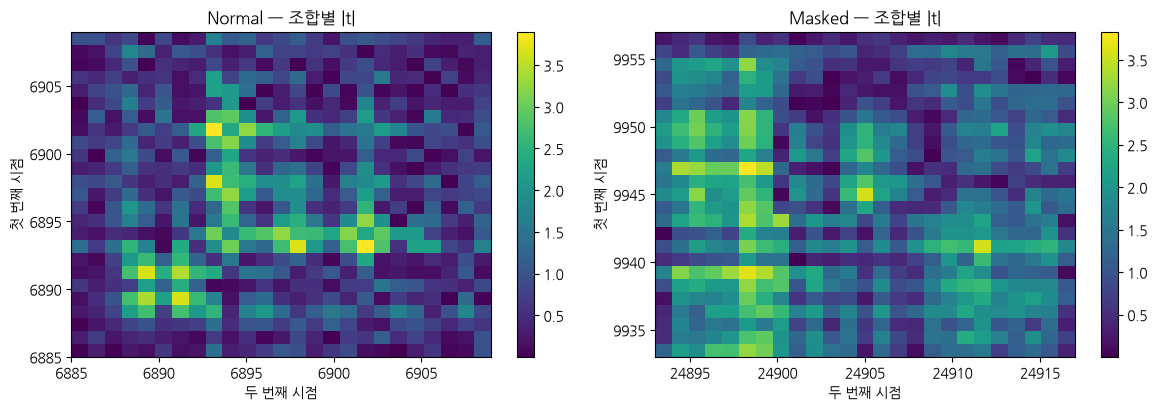

In [4]:
fig, axes = plt.subplots(1, len(mt_res), figsize=(6.0 * len(mt_res), 4.2))
if len(mt_res) == 1:
    axes = [axes]
side = 2 * W + 1
for ax, tid in zip(axes, mt_res):
    v, pois, _ = mt_res[tid]
    im = ax.imshow(v.reshape(side, side), origin="lower", aspect="auto",
                   extent=[pois[1].min(), pois[1].max(),
                           pois[0].min(), pois[0].max()])
    ax.set_title("%s — 조합별 |t|" % TARGETS[tid]["short"])
    ax.set_xlabel("두 번째 시점"); ax.set_ylabel("첫 번째 시점")
    fig.colorbar(im, ax=ax)
fig.tight_layout(); plt.show()

### 결과를 있는 그대로

2차 조합 검정은 **임계를 넘지 못한다.** 이것은 실패한 실험이 아니라 결과다.

1.0 §10 에서 확인했듯 정보 자체는 파형에 남아 있다 — 마스크를 알면 SNR 이 바닥의 3배로
살아났다. 그런데 마스크를 **모른 채** 두 시점의 곱으로 그 정보를 끄집어내려면 훨씬 많은
트레이스가 필요하다. 이유는 통계적이다.

- 1차 통계는 평균 하나를 추정한다. 오차가 $1/\sqrt{n}$ 로 준다.
- 2차 통계는 두 시점의 곱의 평균을 추정한다. 각 시점의 잡음이 곱해져 들어오므로
  **같은 확신에 도달하는 데 필요한 장수가 훨씬 빠르게 늘어난다.**

이것이 마스킹이 실제로 제공하는 방어다. 마스킹은 누설을 **없애지** 않는다.
누설을 끌어내는 **비용을 올린다.** 우리가 가진 10,000장은 그 비용을 감당하지 못한다.

> 이 노트북에서 "2차로 뚫었다" 고 말하지 않는 이유다. 안 되면 안 된 것으로 적는다.

---
## 4. 연구자 — 마스크를 알면 조합이 필요 없다

3절이 어려웠던 이유는 $m_5$ 를 **추정**해야 했기 때문이다.
$m_5$ 를 그냥 알면 곱할 필요 없이 1차로 끝난다.

라벨을 $\mathrm{SBOX}[p \oplus k] \oplus m_5$ 의 최하위 비트로 바꾸기만 하면 된다.
파형도, 장수도, API 도 그대로다.

In [5]:
tid = "masked-aes-c"
if tid not in data or data[tid]["m"] is None:
    print("Masked i_m 없음 — 연구자 절 skip")
else:
    d = data[tid]
    lo = int(poi[tid]["enc_start"])
    key = np.array(d["attrs"]["fixed_key"], dtype=np.uint8)
    m5 = d["m"][:, 5]

    rows = [
        ("공격자 : SBOX[p^k] 의 LSB",
         (sbox_out(d["p"][:, BYTE], key[BYTE]) & 1)),
        ("연구자 : (SBOX[p^k] ^ m5) 의 LSB",
         (np.bitwise_xor(sbox_out(d["p"][:, BYTE], key[BYTE]), m5) & 1)),
        ("연구자 : m5 의 LSB",
         (m5 & 1)),
    ]
    print("%-36s %12s %12s" % ("라벨", "1차 max|t|", "임계 초과"))
    for name, y in rows:
        tt = Ttest(d=1)
        tt.fit_u(np.ascontiguousarray(d["t"]), y.astype(np.uint16))
        v = np.abs(tt.get_ttest())[0, lo:]
        print("%-36s %12.2f %12d" % (name, np.nanmax(v), int((v > THR).sum())))

    print()
    print("같은 10,000장, 같은 1차 검정이다. 마스크를 아느냐만 다르다.")
    print("3절에서 조합으로도 못 넘긴 임계를, 여기서는 시점 하나로 넘는다.")

라벨                                      1차 max|t|        임계 초과
공격자 : SBOX[p^k] 의 LSB                        4.90            2
연구자 : (SBOX[p^k] ^ m5) 의 LSB                20.86           58
연구자 : m5 의 LSB                              33.19         7449

같은 10,000장, 같은 1차 검정이다. 마스크를 아느냐만 다르다.
3절에서 조합으로도 못 넘긴 임계를, 여기서는 시점 하나로 넘는다.


---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | **시점 조합**의 누설을 검정한다 — 마스킹 구현의 표준 평가 방법 |
| API | `MTtest(d, pois)` → `fit_u(traces, x)` → `get_ttest()` → `(n_points,)` |
| `pois` | `(d, n_points)` `uint32` **C 연속**. 열 하나가 조합 하나 |
| `x` | `(n,)` `uint16`, 0/1 |
| 조합 근거 | 구현에서 유도한다. `np.roll` 같은 임의 짝짓기는 무의미하다 |

### 이 데이터셋에서 관측한 것

| 관점 | 방법 | 결과 |
|------|------|------|
| Normal · 1차 | 시점 하나 | 크게 초과 — 보호 없음 |
| Masked · 1차 | 시점 하나 | 임계 근처까지만 |
| Masked · 2차 (평가자) | 이상적 조합을 알려줌 | **10,000장으로는 임계 미달** |
| Masked · 연구자 | 마스크 기지, 1차 | 즉시 초과 |

### 6. Masked 의 1차 잔여 누설을 어떻게 읽을 것인가

완전한 1차 마스킹이라면 1차 통계는 비밀에 대해 아무것도 말하지 않아야 한다.
그런데 실제 구현에서 $|t|$ 가 임계 근처에 걸치는 일은 드물지 않다. 위 표의 Masked
1차 값이 임계 근처거나 그 이상이라면 원인 후보는 이렇다.

1. **글리치·전이 누설.** 레지스터가 $v \oplus m$ 에서 $m$ 으로 바뀔 때의 **전이**가
   $v$ 에 의존한다. 값 자체는 가려져도 값의 *변화*가 새는 것이라, 소프트웨어 마스킹이
   하드웨어에서 가장 흔히 깨지는 지점이다. 마스킹 이론은 보통 이 경로를 모형에 넣지 않는다.
2. **마스크 난수의 품질.** 마스킹의 안전성 논거는 마스크가 **균일**하고 매번 새로
   뽑힌다는 전제 위에 있다. 전제가 깨지면 그만큼 1차 누설이 남는다.
   이 데이터셋의 마스크 품질은 `1.0` §11 에서 확인한다.
3. **통계적 여유.** 10,000장에서 $|t|$ 가 4.5 를 조금 넘는 것은 강한 증거가 아니다.
   4.5 는 경보선이지 판정선이 아니며, 장수를 늘리면 $|t|$ 는 $\sqrt{n}$ 으로 커진다.
   §2 의 장수별 표와 함께 읽어야 한다.

가르는 방법은 정해져 있다. 2번은 `1.0` §11 의 마스크 점검으로 즉시 배제하거나 확인할 수 있고,
3번은 장수를 바꿔 가며 $|t|$ 가 어떻게 자라는지 보면 된다. 둘 다 아니면 1번이 남는데,
그것은 이 구현·이 하드웨어의 성질이지 마스킹이라는 대책의 한계가 아니다.

### 실패 시 점검

1. `pois` 를 `uint32`·C 연속으로 만들지 않으면 예외가 나거나 결과가 이상하다.
2. `get_ttest()` 의 결과는 `(n_points,)` 다. `(d, ns)` 를 기대하면 안 된다.
3. 2차에서 아무것도 안 나온다 → 대개 **장수 부족**이거나 **조합 근거가 틀린** 것이다.
   1.0 의 SNR 로 각 공유값이 실제로 어디서 새는지부터 확인한다.

다음: `3.0.CPA.ipynb` — 진단이 아니라 실제 키 복구.